In [1]:
import os
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
# Download NLTK data to a local folder and add it to search paths
nltk_data_dir = os.path.join(os.getcwd(), "output/nltk_data")
os.makedirs(nltk_data_dir, exist_ok=True)
if nltk_data_dir not in nltk.data.path:
    nltk.data.path.insert(0, nltk_data_dir)

nltk.download('punkt', download_dir=nltk_data_dir)
nltk.download('punkt_tab', download_dir=nltk_data_dir)  # required by newer NLTK
nltk.download('stopwords', download_dir=nltk_data_dir)

nltk.download('punkt')
nltk.download('stopwords')

# import data
train_path = "data/Corona_NLP_train.csv"
test_path  = "data/Corona_NLP_test.csv"

train_df = pd.read_csv(train_path, encoding="latin-1", low_memory=False)
test_df  = pd.read_csv(test_path,  encoding="latin-1", low_memory=False)

[nltk_data] Downloading package punkt to
[nltk_data]     /home/stepan/Documents/Uni/fcourse/ML/output/nltk_data
[nltk_data]     ...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/stepan/Documents/Uni/fcourse/ML/output/nltk_data
[nltk_data]     ...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/stepan/Documents/Uni/fcourse/ML/output/nltk_data
[nltk_data]     ...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /home/stepan/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/stepan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# data overview
print("Train shape:", train_df.shape)
train_df.info()
display(train_df.describe())
display(train_df.head(7))

print("\n" + "-"*40 + "\n")

print("Test shape:", test_df.shape)
test_df.info()
display(test_df.describe())
display(test_df.head(7))

Train shape: (41157, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41157 entries, 0 to 41156
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserName       41157 non-null  int64 
 1   ScreenName     41157 non-null  int64 
 2   Location       32567 non-null  object
 3   TweetAt        41157 non-null  object
 4   OriginalTweet  41157 non-null  object
 5   Sentiment      41157 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.9+ MB


,UserName,ScreenName
count,41157.000000,41157.000000
mean,24377.000000,69329.000000
std,11881.146851,11881.146851
min,3799.000000,48751.000000
25%,14088.000000,59040.000000
50%,24377.000000,69329.000000
75%,34666.000000,79618.000000
max,44955.000000,89907.000000


,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative
5,3804,48756,"ÃT: 36.319708,-82.363649",16-03-2020,As news of the regionÂs first confirmed COVID...,Positive
6,3805,48757,"35.926541,-78.753267",16-03-2020,Cashier at grocery store was sharing his insig...,Positive



----------------------------------------

Test shape: (3798, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3798 entries, 0 to 3797
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   UserName       3798 non-null   int64 
 1   ScreenName     3798 non-null   int64 
 2   Location       2964 non-null   object
 3   TweetAt        3798 non-null   object
 4   OriginalTweet  3798 non-null   object
 5   Sentiment      3798 non-null   object
dtypes: int64(2), object(4)
memory usage: 178.2+ KB


,UserName,ScreenName
count,3798.000000,3798.000000
mean,1899.500000,46851.500000
std,1096.532489,1096.532489
min,1.000000,44953.000000
25%,950.250000,45902.250000
50%,1899.500000,46851.500000
75%,2848.750000,47800.750000
max,3798.000000,48750.000000


,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,1,44953,NYC,02-03-2020,TRENDING: New Yorkers encounter empty supermar...,Extremely Negative
1,2,44954,"Seattle, WA",02-03-2020,When I couldn't find hand sanitizer at Fred Me...,Positive
2,3,44955,NaN,02-03-2020,Find out how you can protect yourself and love...,Extremely Positive
3,4,44956,Chicagoland,02-03-2020,#Panic buying hits #NewYork City as anxious sh...,Negative
4,5,44957,"Melbourne, Victoria",03-03-2020,#toiletpaper #dunnypaper #coronavirus #coronav...,Neutral
5,6,44958,Los Angeles,03-03-2020,Do you remember the last time you paid $2.99 a...,Neutral
6,7,44959,NaN,03-03-2020,Voting in the age of #coronavirus = hand sanit...,Positive


In [4]:
# missing values
print("Missing values in train set:\n", train_df.isnull().sum())
print("\nMissing values in test set:\n", test_df.isnull().sum())

Missing values in train set:
 UserName            0
ScreenName          0
Location         8590
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64

Missing values in test set:
 UserName           0
ScreenName         0
Location         834
TweetAt            0
OriginalTweet      0
Sentiment          0
dtype: int64


Distribution of simplified sentiment classes:
Sentiment
Positive    19592
Negative    17031
Other        8332
Name: count, dtype: int64


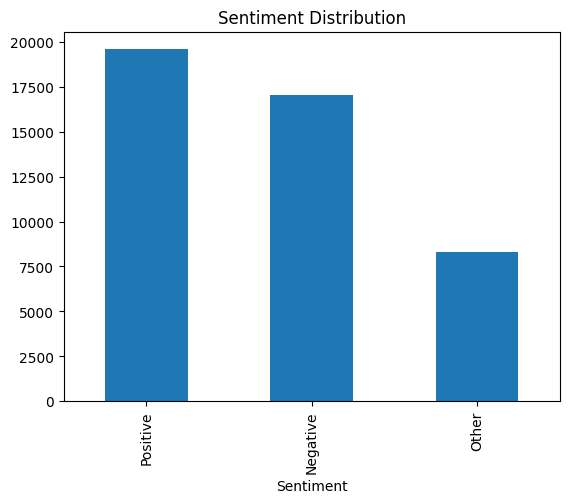


--- Example of Cleaning ---
Original Tweet: As news of the regionÂs first confirmed COVID-19 case came out of Sullivan County last week, people flocked to area stores to purchase cleaning supplies, hand sanitizer, food, toilet paper and other goods, @Tim_Dodson reports https://t.co/cfXch7a2lU
Cleaned Tokens: ['news', 'first', 'confirmed', 'case', 'came', 'sullivan', 'county', 'last', 'week', 'people', 'flocked', 'area', 'stores', 'purchase', 'cleaning', 'supplies', 'hand', 'sanitizer', 'food', 'toilet', 'paper', 'goods', 'reports']


In [5]:
# Об'єднуємо датафрейми для однакової обробки
df = pd.concat([train_df, test_df], ignore_index=True)

# Simplify sentiment labels
def simplify_sentiment(sentiment):
    if sentiment in ['Extremely Negative', 'Negative']:
        return 'Negative'
    elif sentiment in ['Extremely Positive', 'Positive']:
        return 'Positive'
    else:
        return 'Other'

df['Sentiment'] = df['Sentiment'].apply(simplify_sentiment)

# Check the new distribution of classes
print("Distribution of simplified sentiment classes:")
print(df['Sentiment'].value_counts())
hist = df['Sentiment'].value_counts().plot(kind='bar', title='Sentiment Distribution')
plt.show()

# Define the set of stop words once
stop_words = set(stopwords.words('english'))

# Function to clean and tokenize tweet text
def clean_tweet(text):
    if not isinstance(text, str):
        return []
    # Remove URLs, mentions, and hashtags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#','', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenize the text
    tokens = word_tokenize(text)
    # Remove stop words and non-alphabetic characters
    filtered_tokens = [word for word in tokens if word.isalpha() and word not in stop_words]
    return filtered_tokens

# Apply the cleaning function
df['Cleaned_Tokens'] = df['OriginalTweet'].apply(clean_tweet)

print("\n--- Example of Cleaning ---")
print("Original Tweet:", df['OriginalTweet'].iloc[5])
print("Cleaned Tokens:", df['Cleaned_Tokens'].iloc[5])


Модель Word2Vec навчено.


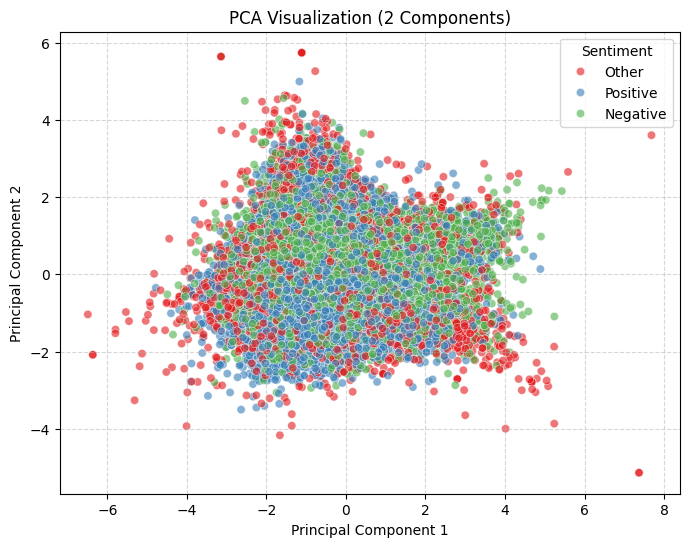


Розмір тренувальної вибірки: (35964, 300)
Розмір тестової вибірки: (8991, 300)


In [6]:
# Навчання моделі Word2Vec
# size: розмірність векторів, window: контекстне вікно, min_count: мінімальна частота слова
w2v_model = Word2Vec(sentences=df['Cleaned_Tokens'], vector_size=300, window=5, min_count=2, workers=4)
print("\nМодель Word2Vec навчено.")

# Функція для перетворення твіту на вектор (усередненням)
def tweet_to_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

# Створюємо векторні представлення для всіх твітів
df['Tweet_Vector'] = df['Cleaned_Tokens'].apply(lambda tokens: tweet_to_vector(tokens, w2v_model))

# Розділяємо дані на ознаки (X) та цільову змінну (y)
X = np.array(df['Tweet_Vector'].tolist())
y = df['Sentiment']

# ---- PCA Visualization in 2D ----
pca_viz = PCA(n_components=2)
X_pca_2d = pca_viz.fit_transform(X)

# Створюємо DataFrame для зручності візуалізації
pca_df = pd.DataFrame({
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1],
    'Sentiment': y
})

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=pca_df,
    x='PC1', y='PC2',
    hue='Sentiment',
    palette='Set1',
    alpha=0.6
)
plt.title('PCA Visualization (2 Components)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Sentiment')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# [cite_start]Поділ даних на тренувальну та тестову вибірки (80/20) [cite: 21]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nРозмір тренувальної вибірки: {X_train.shape}")
print(f"Розмір тестової вибірки: {X_test.shape}")

In [7]:
# Визначаємо моделі для тестування
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine": SVC(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB()
}

# Кількість компонент для PCA. None означає без PCA
pca_components = [None, 50, 100, 200]

results = []

# Цикл для навчання та оцінки кожної моделі з різними налаштуваннями PCA
for model_name, model in models.items():
    for n_components in pca_components:
        if n_components:
            # Створюємо пайплайн з PCA та класифікатором
            pipeline = Pipeline([
                ('pca', PCA(n_components=n_components)),
                ('classifier', model)
            ])
            pca_label = f"{n_components} components"
        else:
            # Створюємо пайплайн тільки з класифікатором
            pipeline = Pipeline([('classifier', model)])
            pca_label = "No PCA"

        # Навчаємо модель
        pipeline.fit(X_train, y_train)
        
        # Робимо прогнози
        y_pred = pipeline.predict(X_test)
        
        # Оцінюємо модель
        accuracy = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)
        
        # Зберігаємо результати
        results.append({
            "Model": model_name,
            "PCA": pca_label,
            "Accuracy": accuracy,
            "Precision (Positive)": report['Positive']['precision'],
            "Recall (Positive)": report['Positive']['recall'],
            "F1-score (Positive)": report['Positive']['f1-score'],
            "Precision (Negative)": report['Negative']['precision'],
            "Recall (Negative)": report['Negative']['recall'],
            "F1-score (Negative)": report['Negative']['f1-score']
        })
        print(f"Завершено: {model_name} з {pca_label}")

# Створюємо DataFrame з результатами для зручного перегляду
results_df = pd.DataFrame(results)

Завершено: Logistic Regression з No PCA
Завершено: Logistic Regression з 50 components
Завершено: Logistic Regression з 100 components
Завершено: Logistic Regression з 200 components


KeyboardInterrupt: 

In [ ]:
# Виводимо таблицю з результатами
print("\nТаблиця з результатами класифікації:")
display(results_df)


Таблиця з результатами класифікації:


,Model,PCA,Accuracy,Precision (Positive),Recall (Positive),F1-score (Positive),Precision (Negative),Recall (Negative),F1-score (Negative)
0,Logistic Regression,No PCA,0.602491,0.620682,0.724604,0.668629,0.593394,0.611861,0.602486
1,Logistic Regression,50 components,0.586364,0.602492,0.715671,0.654223,0.577829,0.590722,0.584204
2,Logistic Regression,100 components,0.602714,0.620848,0.725115,0.668943,0.593447,0.611568,0.602371
3,Logistic Regression,200 components,0.603826,0.621639,0.725881,0.669728,0.595265,0.612742,0.603877
4,Support Vector Machine,No PCA,0.602269,0.605613,0.732517,0.663047,0.594096,0.614504,0.604128
5,Support Vector Machine,50 components,0.604938,0.611087,0.720265,0.661200,0.596175,0.622431,0.609020
6,Support Vector Machine,100 components,0.606718,0.612812,0.720265,0.662208,0.598036,0.625954,0.611677
7,Support Vector Machine,200 components,0.606940,0.612980,0.720776,0.662522,0.598204,0.625954,0.611765
8,Random Forest,No PCA,0.591592,0.599824,0.697805,0.645116,0.581034,0.593658,0.587279
9,Random Forest,50 components,0.601935,0.604626,0.727157,0.660255,0.591631,0.601879,0.596711



Побудова графіка впливу PCA на точність моделей...
Графік збережено у файл: pca_impact_on_accuracy.png


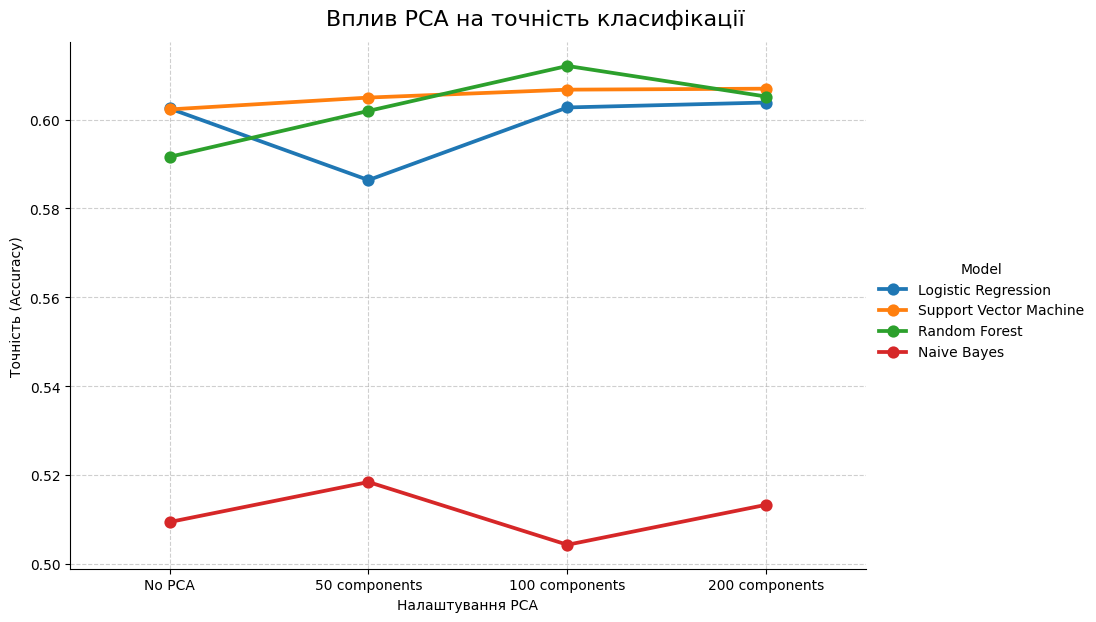

In [ ]:
print("\nПобудова графіка впливу PCA на точність моделей...")

# Для коректного сортування на осі X, визначимо порядок
pca_order = ['No PCA', '50 components', '100 components', '200 components']

# Використовуємо catplot (kind='point') для наочного порівняння
# Він автоматично створює сітку та керує розміром
g = sns.catplot(
    data=results_df,
    x='PCA',
    y='Accuracy',
    hue='Model',        # Кожна модель матиме свій колір
    kind='point',       
    order=pca_order,    # Застосовуємо правильний порядок на осі X
    height=6,           # Висота графіка
    aspect=1.5          # Співвідношення сторін (ширина = height * aspect)
)

# Додаємо загальний заголовок
g.fig.suptitle('Вплив PCA на точність класифікації', y=1.03, fontsize=16)
g.set_axis_labels('Налаштування PCA', 'Точність (Accuracy)')
g.ax.grid(True, linestyle='--', alpha=0.6)

pca_impact_plot_path = "pca_impact_on_accuracy.png"
g.savefig(pca_impact_plot_path)

print(f"Графік збережено у файл: {pca_impact_plot_path}")

In [ ]:
nltk_data_dir = os.path.join(os.getcwd(), "nltk_data")

os.makedirs(nltk_data_dir, exist_ok=True)


if nltk_data_dir not in nltk.data.path:
    nltk.data.path.append(nltk_data_dir)

nltk.download('punkt', download_dir=nltk_data_dir)
nltk.download('stopwords', download_dir=nltk_data_dir)


train_path = "data/Corona_NLP_train.csv"
test_path  = "data/Corona_NLP_test.csv"

train_df = pd.read_csv(train_path, encoding="latin-1", low_memory=False)
test_df  = pd.read_csv(test_path,  encoding="latin-1", low_memory=False)

print("Дані успішно завантажено. Пакети NLTK налаштовано для локального використання.")

Дані успішно завантажено. Пакети NLTK налаштовано для локального використання.


[nltk_data] Downloading package punkt to
[nltk_data]     /home/stepan/Documents/Uni/fcourse/ML/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/stepan/Documents/Uni/fcourse/ML/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Найкраща конфігурація моделі:
Model                    Random Forest
PCA                     100 components
Accuracy                      0.612057
Precision (Positive)          0.605501
Recall (Positive)             0.752935
F1-score (Positive)           0.671217
Precision (Negative)          0.606514
Recall (Negative)              0.60687
F1-score (Negative)           0.606692
Name: 10, dtype: object


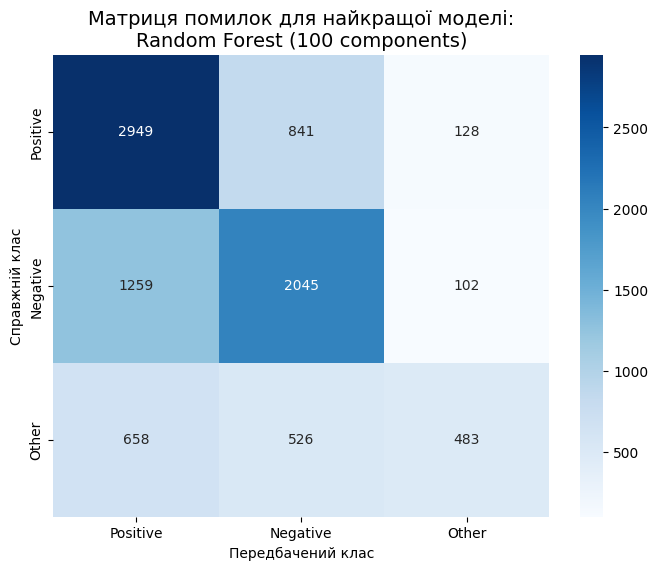

In [ ]:
# Знаходимо найкращу модель за точністю
best_model_config = results_df.loc[results_df['Accuracy'].idxmax()]
print("Найкраща конфігурація моделі:")
print(best_model_config)

# Перенавчаємо найкращу модель, щоб отримати матрицю помилок
best_model_name = best_model_config['Model']
best_pca_str = best_model_config['PCA']

model_to_run = models[best_model_name]

if 'components' in best_pca_str:
    n_components = int(best_pca_str.split()[0])
    final_pipeline = Pipeline([
        ('pca', PCA(n_components=n_components)),
        ('classifier', model_to_run)
    ])
else:
    final_pipeline = Pipeline([('classifier', model_to_run)])

final_pipeline.fit(X_train, y_train)
y_pred_best = final_pipeline.predict(X_test)

# Будуємо матрицю помилок
cm = confusion_matrix(y_test, y_pred_best, labels=['Positive', 'Negative', 'Other'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Positive', 'Negative', 'Other'], 
            yticklabels=['Positive', 'Negative', 'Other'])
plt.title(f'Матриця помилок для найкращої моделі:\n{best_model_name} ({best_pca_str})', fontsize=14)
plt.ylabel('Справжній клас')
plt.xlabel('Передбачений клас')
plt.show()

# Документація до практичної роботи №3
---

## 1. Постановка задачі

Основною метою роботи є побудова та оцінка моделей машинного навчання для **класифікації тональності твітів** про COVID-19. Кожен твіт необхідно віднести до одного з трьох класів: **Positive**, **Negative** або **Other**.

Ключовою особливістю завдання є використання векторних представлень слів (**Word Embeddings**), отриманих за допомогою алгоритму **Word2Vec**, як вхідних ознак для класифікаторів. Додатково досліджується вплив методу головних компонент (**PCA**) на якість класифікації шляхом зниження розмірності простору ознак.

---

## 2. Підготовка даних та векторизація

Цей етап є фундаментом для побудови якісних моделей і включає попередню обробку текстових даних та їх перетворення у числовий формат.

### 2.1. Попередня обробка тексту (Text Preprocessing)

Перед векторизацією кожен твіт проходить стандартизовану процедуру очищення для видалення "шуму" та приведення тексту до єдиного формату. Основні кроки:
1.  **Приведення до нижнього регістру**: Усі символи тексту переводяться в нижній регістр, щоб слова "Covid" та "covid" вважалися однаковими.
2.  **Токенізація**: Текст розбивається на окремі слова (токени).
3.  **Видалення стоп-слів**: Видаляються слова, що часто зустрічаються, але не несуть значного семантичного навантаження (наприклад, "a", "the", "is", "in").
4.  **Очищення**: Видаляються URL-адреси, згадки користувачів (`@username`), хештеги (`#`) та інші символи, що не є літерами.

### 2.2. Векторизація за допомогою Word2Vec

Оскільки моделі машинного навчання працюють з числами, а не з текстом, очищені твіти необхідно перетворити на числові вектори.

**Word2Vec** — це алгоритм, який навчається векторним представленням слів (embeddings) на великому текстовому корпусі. Основна ідея полягає в тому, що слова зі схожим контекстом (тобто ті, що вживаються поруч з однаковими словами) матимуть близькі за значенням вектори.

Щоб отримати єдиний вектор для всього твіту, застосовується підхід усереднення векторів усіх слів, що входять до нього:
$$
\vec{v}_{tweet} = \frac{1}{N} \sum_{i=1}^{N} \vec{w}_i
$$
де:
- $N$ — кількість слів у твіті, для яких існують вектори.
- $\vec{w}_i$ — вектор $i$-го слова з моделі Word2Vec.

---

## 3. Зниження розмірності (PCA)

Після векторизації кожен твіт представлений вектором високої розмірності. Метод головних компонент (PCA) використовується для зменшення цієї розмірності.

**PCA** — це алгоритм, який перетворює вихідний набір корелюючих ознак у новий набір лінійно некорельованих ознак, які називаються **головними компонентами**. Він сортує ці компоненти за дисперсією, що дозволяє відкинути менш значущі компоненти, зберігши при цьому максимум інформації.

У роботі проводиться експеримент з різною кількістю компонент (50, 100, 200) для аналізу впливу цього процесу на точність моделей.

---

## 4. Побудова та навчання моделей

Для вирішення задачі класифікації використовуються чотири різні моделі з бібліотеки `scikit-learn`.

### 4.1. Моделі для класифікації

| Модель | Короткий опис |
|---|---|
| **Logistic Regression** | Лінійний класифікатор, що прогнозує ймовірність належності до класу. |
| **Support Vector Machine (SVM)** | Знаходить оптимальну гіперплощину, яка найкращим чином розділяє класи у просторі ознак. |
| **Random Forest** | Ансамблевий метод, що усереднює прогнози великої кількості незалежних дерев рішень. |
| **Naive Bayes** | Імовірнісний класифікатор, що базується на теоремі Баєса та припущенні про незалежність ознак. |

### 4.2. Використання `Pipeline`

Для об'єднання кроків обробки даних (PCA) та навчання моделі в єдиний процес використовується `scikit-learn Pipeline`. Це гарантує, що на валідаційних та тестових даних застосовуються ті ж самі перетворення, що й на тренувальних, що запобігає витоку даних.

Структура пайплайну:
1.  **Етап 1 (опційно)**: Зниження розмірності за допомогою PCA.
2.  **Етап 2**: Навчання класифікатора.

---

## 5. Метрики оцінки

Для всебічної оцінки якості моделей використовуються стандартні метрики класифікації.

| Метрика | Опис |
|---|---|
| **Accuracy** | Частка правильно класифікованих твітів. Загальний показник ефективності. |
| **Precision** | Точність. Показує, яка частка об'єктів, названих класифікатором позитивними, дійсно є такими. |
| **Recall** | Повнота. Показує, яку частку об'єктів позитивного класу було знайдено. |
| **F1-score** | Гармонійне середнє між Precision та Recall. Корисний для датасетів з дисбалансом класів. |
| **Confusion Matrix** | Матриця помилок. Дозволяє візуально оцінити, які класи модель плутає між собою. |

Всі метрики (окрім Accuracy) розраховуються для кожного класу окремо.

---

## 6. Представлення та аналіз результатів

Результати експериментів подаються у структурованому вигляді для полегшення аналізу.

1.  **Таблиця з метриками**: Зведена таблиця, що показує значення всіх метрик для кожної моделі при різній кількості компонент PCA.
2.  **Графіки впливу PCA**: Візуалізація залежності точності (Accuracy) кожної моделі від кількості головних компонент.
3.  **Матриця помилок**: Confusion Matrix для найкращої моделі з метою детального аналізу її помилок.
4.  **Висновки**: На основі отриманих даних формулюються висновки щодо:
    - Найкращої моделі для даної задачі.
    - Впливу PCA на якість класифікації (покращило чи погіршило).
    - Загальної інтерпретації результатів.

# Підсумки та результати роботи



Нижче зібрано короткий огляд виконаних кроків, отриманих артефактів та поради для інтерпретації.



## Що зроблено

- Завантажено дані з `data/Corona_NLP_train.csv` та `data/Corona_NLP_test.csv`.

- Об’єднано у спільний датафрейм і спрощено мітки тональності до трьох класів: `Positive`, `Negative`, `Other`.

- Проведено попередню обробку тексту: очищення URL/@/#, нижній регістр, токенізація, видалення стоп-слів.

- Навчено Word2Vec (vector_size=300) і побудовано вектори твітів через усереднення словних векторів.

- Розбито дані на train/test (80/20, stratify).

- Порівняно 4 моделі (LogReg, SVM, RandomForest, NaiveBayes) з налаштуваннями PCA: `No PCA`, `50`, `100`, `200` компонент.

- Для кожної комбінації зібрано метрики (Accuracy, Precision/Recall/F1 окремо по класах).



## Де подивитися результати

- Підсумкова таблиця з усіма комбінаціями: змінна `results_df` (виведена у попередній клітинці).

- Найкраща конфігурація (за Accuracy): виводиться у клітинці з текстом "Найкраща конфігурація моделі".

- Візуалізація впливу PCA на точність (по всіх моделях): файл `pca_impact_on_accuracy.png` збережено в корені проєкту.

- Детальний розбір помилок найкращої моделі: матриця помилок (heatmap) у відповідній клітинці (підпис `Матриця помилок...`).



## Як інтерпретувати

- Якщо різниця між `No PCA` та PCA незначна, PCA можна опустити для спрощення. Якщо ж з PCA точність зростає — є сенс фіксувати відповідне `n_components`.

- Порівнюйте не лише `Accuracy`, а й F1 для `Positive`/`Negative`, оскільки дисбаланс класів може спотворювати загальну точність.

- Матриця помилок підкаже, між якими класами йде найбільша плутанина (наприклад, `Other` vs `Positive/Negative`).



## Типові спостереження (з практики)

- Logistic Regression часто дає сильну базу на усереднених embeddings.

- SVM (RBF) може бути конкурентним, але чутливий до масштабу/розмірності.

- Random Forest інколи поступається на щільних векторах без явних розріджених ознак.

- Gaussian NB може програвати через припущення про незалежність ознак і нормальність розподілів.



## Можливі покращення

- Додати macro-F1 і зважений F1 (macro/weighted) до таблиці для збалансованої оцінки.

- Використати стратифіковану крос-валідацію (Stratified K-Fold) замість одного 80/20 спліту.

- Спробувати інші векторизатори: TF-IDF, fastText, Doc2Vec, або sentence-transformers (BERT-like).

- Врахувати дисбаланс (class weights, oversampling/SMOTE).



Якщо потрібно, можу автоматично зберігати `results_df` у CSV та друкувати короткий текстовий звіт (модель + PCA + метрики) у вигляді підсумку.